In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from groundingdino.util.inference import load_model, load_image, predict, annotate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

config_path  = "/anaconda/envs/azureml_py38/lib/python3.10/site-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py"
weights_path = "/home/azureuser/cloudfiles/code/Users/Hiba.ELBOUANANI/weights/groundingdino_swint_ogc.pth"
# Charger le modèle
model = load_model(config_path, weights_path)
print("✅ Grounding DINO chargé")

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.wa

✅ Grounding DINO chargé


In [3]:
def run_grounding_dino(image_path, prompt, box_threshold=0.30, text_threshold=0.25):
    """
    image_path     : chemin vers le screen ERP
    prompt         : ce que tu cherches, séparé par des points
    box_threshold  : confiance minimale pour garder une boîte (0.0 à 1.0)
    text_threshold : confiance minimale sur le label
    """
    image_source, image = load_image(image_path)
    
    boxes, scores, labels = predict(
        model=model,
        image=image,
        caption=prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
        device=device
    )
    
    print(f"✅ {len(boxes)} éléments détectés")
    return image_source, boxes, scores, labels

In [4]:
def visualize_dino(image_path, prompt, box_threshold=0.30, text_threshold=0.25):
    image_source, boxes, scores, labels = run_grounding_dino(
        image_path, prompt, box_threshold, text_threshold
    )
    
    # Image annotée par Grounding DINO
    annotated = annotate(
        image_source=image_source,
        boxes=boxes,
        logits=scores,
        phrases=labels
    )
    
    # Afficher
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Image originale
    axes[0].imshow(image_source)
    axes[0].set_title("Image originale", fontsize=13)
    axes[0].axis("off")
    
    # Image annotée
    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Grounding DINO — {len(boxes)} détections", fontsize=13)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.savefig("resultat_dino.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Résumé console
    print("\n📄 Détail des détections :")
    print("="*60)
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        print(f"[{i+1:02d}] score: {score:.2f} | {label:20s} | bbox: {box.tolist()}")
    
    return boxes, scores, labels

✅ 39 éléments détectés


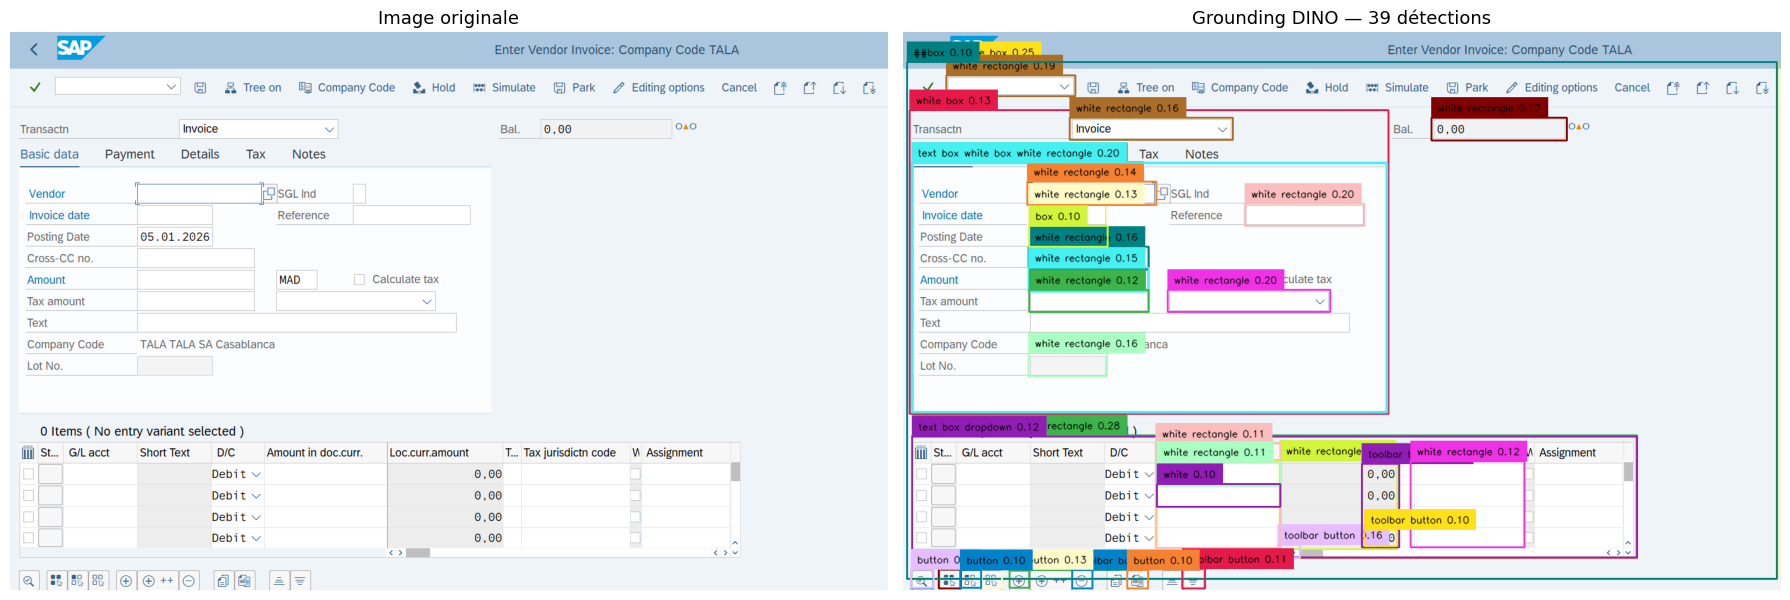


📄 Détail des détections :
[01] score: 0.32 | text box white box white rectangle | bbox: [0.2811190187931061, 0.4581746459007263, 0.5413556098937988, 0.44507741928100586]
[02] score: 0.28 | text box white box white rectangle | bbox: [0.42318204045295715, 0.8327252864837646, 0.826065719127655, 0.2190837860107422]
[03] score: 0.25 | text box white box   | bbox: [0.5003633499145508, 0.5164723992347717, 0.9907363057136536, 0.9254442453384399]
[04] score: 0.22 | toolbar button       | bbox: [0.022054096683859825, 0.9796715378761292, 0.025874808430671692, 0.0341515839099884]
[05] score: 0.19 | text box checkbox    | bbox: [0.42278435826301575, 0.8336678743362427, 0.8252350091934204, 0.21834175288677216]
[06] score: 0.12 | text box dropdown    | bbox: [0.4231923222541809, 0.833252489566803, 0.8259711861610413, 0.21712304651737213]
[07] score: 0.21 | text box white box checkbox | bbox: [0.2809350788593292, 0.4582115411758423, 0.5401952862739563, 0.4453158974647522]
[08] score: 0.20 | white rec

In [8]:
prompt = "text box . white box . white rectangle . dropdown . checkbox . table . toolbar button . tab"

boxes, scores, labels = visualize_dino(
    image_path="img_1767525774023-copy.png",
    prompt=prompt,
    box_threshold=0.10,   # baisse à 0.20 si trop peu de détections
    text_threshold=0.10   # monte à 0.35 si trop de faux positifs
)

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/transformers/modeling_utils.py:1101: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/groundingdino/models/Grounding

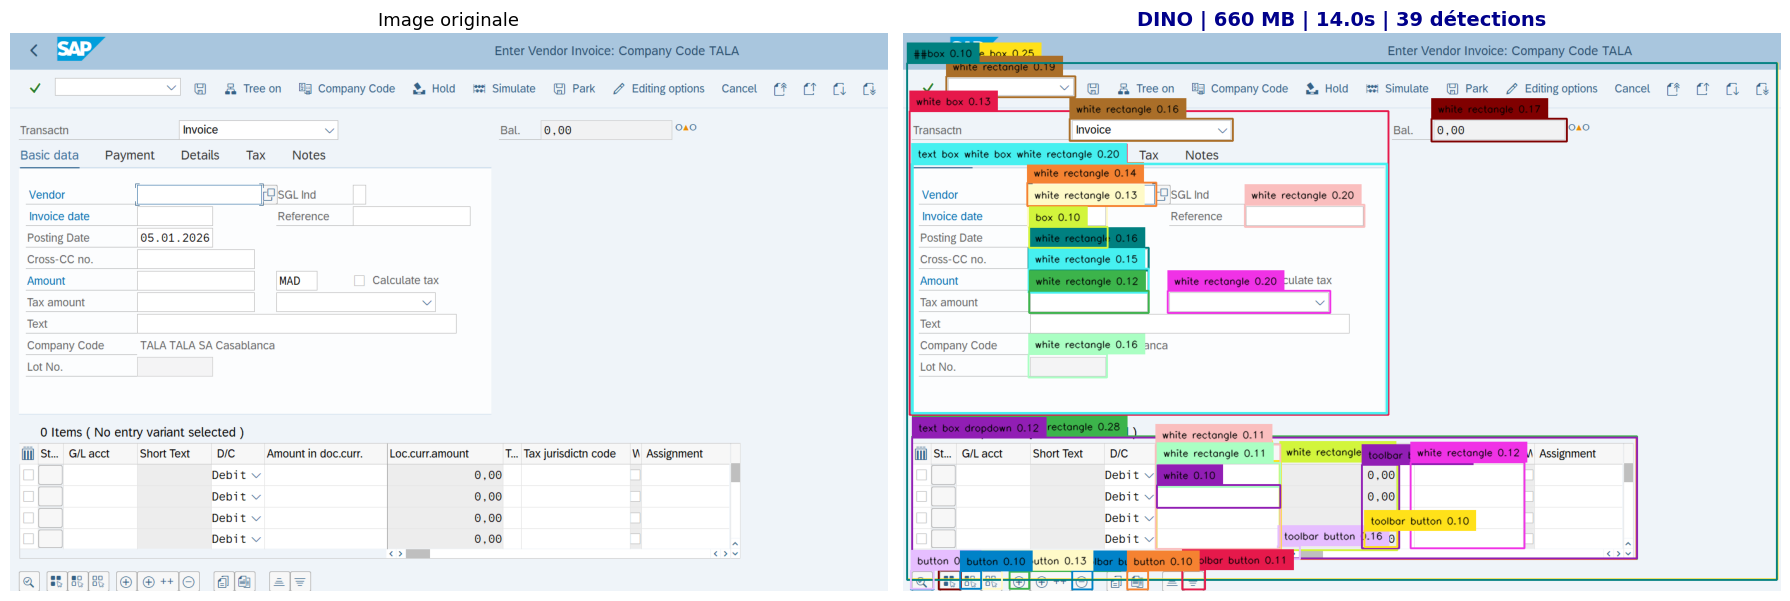

📊 MÉTRIQUES DINO :
   - Poids estimé en RAM : 659.56 MB
   - Vitesse d'inférence : 14032.50 ms (14.03 secondes)


In [3]:
import time
import os
import torch
import cv2
import matplotlib.pyplot as plt

# 1. Fonction pour mesurer le poids (Grounding DINO est souvent chargé en RAM)
def get_dino_weight(model):
    # Calculer le poids des paramètres en mémoire
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb

def visualize_dino_with_metrics(image_path, prompt, box_threshold=0.30, text_threshold=0.25):
    # --- MESURE DE LA VITESSE ---
    image_source, image = load_image(image_path)
    
    # Warm-up (préchauffage CPU)
    _ = predict(model=model, image=image, caption=prompt, 
                box_threshold=box_threshold, text_threshold=text_threshold, device=device)
    
    # Mesure réelle
    start_time = time.time()
    boxes, scores, labels = predict(
        model=model,
        image=image,
        caption=prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
        device=device
    )
    vitesse_ms = (time.time() - start_time) * 1000
    
    # --- RÉCUPÉRATION DU POIDS ---
    poids_mb = get_dino_weight(model)
    
    # --- ANNOTATION ET AFFICHAGE ---
    annotated = annotate(
        image_source=image_source,
        boxes=boxes,
        logits=scores,
        phrases=labels
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(image_source)
    axes[0].set_title("Image originale", fontsize=13)
    axes[0].axis("off")
    
    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    # On affiche les métriques dans le titre pour ta capture d'écran
    titre_metrics = f"DINO | {poids_mb:.0f} MB | {vitesse_ms/1000:.1f}s | {len(boxes)} détections"
    axes[1].set_title(titre_metrics, fontsize=14, color="darkblue", weight="bold")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 MÉTRIQUES DINO :")
    print(f"   - Poids estimé en RAM : {poids_mb:.2f} MB")
    print(f"   - Vitesse d'inférence : {vitesse_ms:.2f} ms ({vitesse_ms/1000:.2f} secondes)")
    
    return boxes, scores, labels

# --- TEST ---
prompt = "text box . white box . white rectangle . dropdown . checkbox . table . toolbar button . tab"

if os.path.exists("img_1767525774023-copy.png"):
    boxes, scores, labels = visualize_dino_with_metrics(
        image_path="img_1767525774023-copy.png",
        prompt=prompt,
        box_threshold=0.10,
        text_threshold=0.10
    )